# The AMAT model in NESTML

This notebook guides you through writing the Augmented Multi-adaptive Threshold (AMAT) model in NESTML, and runs basic simulations and characterisations of the model. This script validates the numerical results, performs a parameter space exploration, and then use the AMAT model in a balanced network.

Prerequisites
-------------

You need to have a working NEST Simulator and NESTML installation, see [Installing NESTML](https://nestml.readthedocs.io/en/latest/installation.html).

You need to be able to run NESTML to generate and build model code. NESTML can be used from the command line, and via a Python API. The latter will be used in this notebook. See [Running NESTML](https://nestml.readthedocs.io/en/latest/running.html).

In [1]:
%matplotlib inline

from typing import Literal, Mapping, Sequence
from dataclasses import dataclass, replace # part of the python library 
import importlib
import matplotlib.pyplot as plt
import nest
import time 
import numpy as np
from pathlib import Path
import sys
from typing import Sequence, Dict, Any, Union
from scipy import stats

import pynestml

from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils
from pynestml.codegeneration.nest_tools import NESTTools

# NEST 3.90, NESTML 8.3.0
# print(pynestml.__version__)


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Feb 25 2026 18:10:15

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



## Introduction to the AMAT model  

The AMAT model adds a voltage-dependent component to the adaptive threshold of the `mat2_psc_exp` neuron.

### Membrane Potential
The subthreshold membrane potential follows leaky integration:
$$ \frac{dV}{dt} = -\frac{V-E_L}{\tau_m} + \frac{I(t)}{C_m} $$
Where $V$ is membrane potential, $E_L$ is resting potential, $\tau_m$ is the membrane time constant, and $I(t)$ is total input current.

### Spike Condition
A spike occurs when the membrane potential crosses the adaptive threshold $\theta(t)$:
$$ V(t) \geq \theta(t) $$
$$ \theta(t) = \omega + \theta_{\alpha_1}(t) + \theta_{\alpha_2}(t) + \theta_V(t) $$

### Spike-History Threshold
The two spike-history components obey:
$$ \frac{d\theta_{\alpha_i}}{dt} = -\frac{\theta_{\alpha_i}}{\tau_i} + \alpha_i \sum_k \delta(t-t_k), \qquad i\in\{1,2\} $$
Here, $\alpha_i$ dictates the threshold increase following a spike, and $\tau_i$ is its decay time constant.

### Voltage-Dependent Threshold
The AMAT extension adds a dynamic voltage-dependent threshold component:
$$ \theta_V(t) = \beta \int_0^\infty K(s)\, \frac{dV}{dt}(t-s)\,ds $$
Using the alpha-function kernel:
$$ K(s)=s\,e^{-s/\tau_V} $$

**Reference:** Yamauchi, S. et al. (2011). *Elemental Spiking Neuron Model for Reproducing Diverse Firing Patterns and Predicting Precise Firing Times* Front. Comput. Neurosci. 
[https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2011.00042/full]

## Formulating the model in NESTML

See the file ``amat_neuron.nestml`` in the neuron models directory (https://github.com/nest/nestml/tree/main/models/neurons/amat_neuron.nestml)

In [2]:
# generate and build code
nestml_module, nestml_neuron_model = NESTCodeGeneratorUtils.generate_code_for(
   "amat_neuron.nestml",
   target_path="benchmark/Running/targets_amat_optimised_cse/target",
   module_name="nestml_amat_cse_module",
   logging_level="DEBUG")

PyGSL is not available. The stiffness test will be skipped.
Error when importing: No module named 'pygsl'


[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /p/project1/paj2623/gray2/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/tmp/nestml_target_vgfpmavx"

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Feb 25 2026 18:10:15

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: v3.9.0
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates directory "/p/project1/paj2623/gray2/src/nestml/pynestml/codegeneration/resources_nest/point_neuro

[ODE-toolbox] INFO:Analysing input:
[ODE-toolbox] INFO:{
    "dynamics": [
        {
            "expression": "I_drive' = 0 / 1.0",
            "initial_values": {
                "I_drive": "I_e"
            }
        },
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_drive) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit

[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [123:0;236:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [123:0;236:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target" !
[16,GLOBAL, INFO]: Rendering template /p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target/nestml_amat_cse_module.h
[17,GLOBAL, INFO]: Rendering template /p/project1/paj2623/gray2/benchmark/Running/targets_amat_optimised_cse/target/nestml_amat_cse_module.cpp
[18,GLOBAL, INFO]: Rendering template /p/project1/paj2623/gray2/benchma

## Formulating the AMAT NEST model 

The file ``amat2_psc_exp`` can be found in the model directory of nestml directory 
(https://github.com/nest/nest-simulator/tree/main/models/amat2_psc_exp.cpp)

This is a handtuned C++ NEST reference model developed in which the NESTML AMAT model will be validated against. 

**Reference:** Heiberg et al.., (2018), *Firing-rate models for neurons with a broad repertoire of spiking behaviors* Front. Comput. Neurosci. 
[https://link.springer.com/article/10.1007/s10827-018-0693-9]


In [3]:
nest_model_name = "amat2_psc_exp"
if nest_model_name not in nest.node_models:
    nest.Install(NESTML_MODULE)
    print(f"{nest_model_name} has been installed & loaded.")
else: 
    print(f"{nest_model_name} was loaded already.")

amat2_psc_exp was loaded already.


## Shared Parameters 

The same phyiscal parameters are supplied to both implementations. One API must cleanly both models handle explicitly. 
For instance there are certain mismatches: 

- NESTML `amat_nestml` expects `omega` as the **absolute** resting threshold
- Native `amat2_psc_exp` evaluates $E_L+\omega$, so it expects a relative threshold **offset above $E_L$**.

For example, with \(E_L=-70\) mV and a resting threshold of \(-65\) mV, native NEST receives `omega=-65`, while NESTML receives `omega=5`.


In [15]:
@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs, ensures params are kept the same 
class AMATConfig:
    
    # Simulation and Pulse Layout
    pulse_times_ms: tuple[float, ...] = (10.0, 30.0, 210.0, 270.0) # Used for standard runs
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 400.0

    # Resonator vs Integrator Sweep Bounds
    first_pulse_ms: float = 10.0 
    response_window_ms: float = 50.0 # Cleaned up duplicate value

    # Membrane and Threshold Parameters
    tau_m_ms: float = 10.0
    C_m_pf: float = 200.0
    t_ref_ms: float = 2.0
    E_L_mv: float = -70.0  # mismatch specified above 
    resting_threshold_mv: float = -50.0 # (-65) 
    
    # Synaptic and Adaptation Time Constants
    tau_syn_ex_ms: float = 1.0
    tau_syn_in_ms: float = 3.0
    tau_1_ms: float = 10.0
    tau_2_ms: float = 200.0
    
    # AMAT Model Specific Adaptation Parameters
    alpha_1_mv: float = 0.0
    alpha_2_mv: float = 0.0
    gamma: float = 1.5
    B: float = 4.0

    # Balanced Network Parameters informed by C.Linssen et al., (2025)
    g: float = 5.0 # ratio of inhib weight/excitatory weight 
    balanced_simtime: float = 1000.0  
    delay: float = 1.0  # synaptic delay in ms 
    eta: float = 1.5 # external rate relative to threshold rate 
    epsilon: float = 0.1 # connection probability 
    order: int = 250 # scale for num_neurons.
    J_ex: float =  0.15   # excitatory synaptic weight, pA
    J_in: float = (g * J_ex) # inhibitory strength * exc weight
    n_record: int = 100 # number of neurons to record from 

    # Background Current
    I_e_pa: float = 0.0

    # Resolution 
    resolution: float = 0.01  # ms 


## Helper functions 

- `run_amat_model`
- `model_parameters`
- `reconstruct_threshold_component`

In [16]:
def model_parameters(model_name, config):
    """Translate one shared parameter set to the selected model API."""
    
    # Parameters that have the same name in both implementations
    params = {
        "tau_m": config.tau_m_ms,
        "C_m": config.C_m_pf,
        "E_L": config.E_L_mv,

        "tau_1": config.tau_1_ms,
        "tau_2": config.tau_2_ms,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,

        # AMAT voltage-dependent threshold
        "tau_v": config.gamma * config.tau_m_ms,
        "beta": config.B / config.tau_m_ms,

        # Absolute resting threshold voltage
        "omega": config.resting_threshold_mv,
        "I_e": config.I_e_pa}

    # Parameters whose names differ between the implementations
    if model_name == "amat2_psc_exp":

        params.update({
            "t_ref": config.t_ref_ms,     # NESTML accepts different naming conventions  
            "tau_syn_ex": config.tau_syn_ex_ms,
            "tau_syn_in": config.tau_syn_in_ms,
        })

    elif model_name == "amat_neuron_nestml":

        params.update({
            "refr_T": config.t_ref_ms,
            "tau_syn_exc": config.tau_syn_ex_ms,
            "tau_syn_inh": config.tau_syn_in_ms,
        })
    else:
        raise ValueError(
            f"Unsupported AMAT model: {model_name}"
        )

    # Only pass parameters actually exposed by the chosen model
    defaults = nest.GetDefaults(model_name)

    params = {
        name: value
        for name, value in params.items()
        if name in defaults}

    return params


def run_amat_model(model_name, config, sweep_experiment=False):
    """Run one AMAT simulation and return a common result dictionary."""
    
    nest.ResetKernel()
    nest.SetKernelStatus({"resolution": config.resolution})
    nest.set_verbosity("M_ERROR")

    if model_name not in nest.Models():
        nest.Install("nestml_amat_module")

    params = model_parameters(
        model_name,
        config)

    neuron = nest.Create(
        model_name, 
        params=model_parameters(model_name, config), # can this be scaled with brunel? 
    )

    amplitude_times = []
    amplitude_values = []
    
    for onset in config.pulse_times_ms:
        amplitude_times.extend([onset, onset + config.pulse_width_ms])
        amplitude_values.extend([config.pulse_amplitude_pa, 0.0])

    
    current = nest.Create(
        "step_current_generator",
        params={
            "amplitude_times": amplitude_times,
            "amplitude_values": amplitude_values,
        },
    )

    defaults = nest.GetDefaults(model_name)
    requested = [ 
        "V_m",
        "V_th",
        "V_th_alpha_1",
        "V_th_alpha_2",
        "V_th_v",
        "V_th_v_aux",
        "I_syn",
    ]
    recordables = [
        name for name in requested
        if name in defaults["recordables"]
    ]

    multimeter = nest.Create( # creating multimeter to record from requested recordables 
        "multimeter",
        params={
            "interval": config.resolution,
            "record_from": recordables,
        },
    )
    spikes = nest.Create("spike_recorder")

    nest.Connect(current, neuron)
    nest.Connect(multimeter, neuron)
    nest.Connect(neuron, spikes) # connecting current, multimeter, spike recorder 
    
    nest.Simulate(config.simulation_time_ms) # simulating 

    events = multimeter.get("events") # gather data from multi meter 
    spike_events = spikes.get("events")
    times = np.asarray(events["times"], dtype=float)

    input_current = np.zeros_like(times)
    for onset in config.pulse_times_ms:
        active = (
            (times >= onset)
            & (times < onset + config.pulse_width_ms)
        )

        if sweep_experiment:
            input_current[active] = (config.pulse_amplitude_pa - 200) # lower amplitude being applied in sweep experiments (800 pA) 
        else:
            input_current[active] = config.pulse_amplitude_pa # (1000pA) 
    
    result = {
        "times": times,
        "input_current": input_current,
        "spike_times": np.asarray(spike_events["times"], dtype=float),
    }

    for name in recordables:
        result[name] = np.asarray(events[name], dtype=float)

    result["distance"] = result["V_m"] - result["V_th"]
    
    return result


def reconstruct_threshold_component(times, spike_times, alpha, tau): 
    component = np.zeros_like(times)

    for spike_time in spike_times: 
    
        # on the timestep AFTER the spike occurs, matching NEST's grid execution loop.
        after_spike = times > spike_time
        
        component[after_spike] += alpha * np.exp(
            -(times[after_spike] - spike_time) / tau
        )

    return component


def reconstruct_threshold_component(times, spike_times, alpha, tau): 
    component = np.zeros_like(times)
    
    # Extract your explicit simulation time step (resolution)
    dt = times[1] - times[0] 

    for spike_time in spike_times: 
       
        after_spike = times > spike_time
        
        # Measure decay elapsed time starting from that next step interval boundary
        elapsed_time = times[after_spike] - (spike_time + dt)
        
        component[after_spike] += alpha * np.exp(-elapsed_time / tau)

    return component



# Comparison between AMAT NEST and NESTML 

Both AMAT models now receive the same current wave forms and physical parameters. We can now overlay and compare their activities across two injected pulses at 10.0, 30.0, 210.0 and 270.0 ms. 

[INFO] Trace comparison
V_m             MAE=8.96053e-14  RMSE=1.1447e-13  max|Δ|=4.40536e-13
V_th            MAE=0.0933619  RMSE=0.0964194  max|Δ|=0.11411
V_th_alpha_1    MAE=0  RMSE=0  max|Δ|=0
V_th_alpha_2    MAE=0  RMSE=0  max|Δ|=0
V_th_v          MAE=0.0933619  RMSE=0.0964194  max|Δ|=0.11411

[INFO] Detected spike times
NEST  : []
NESTML: []


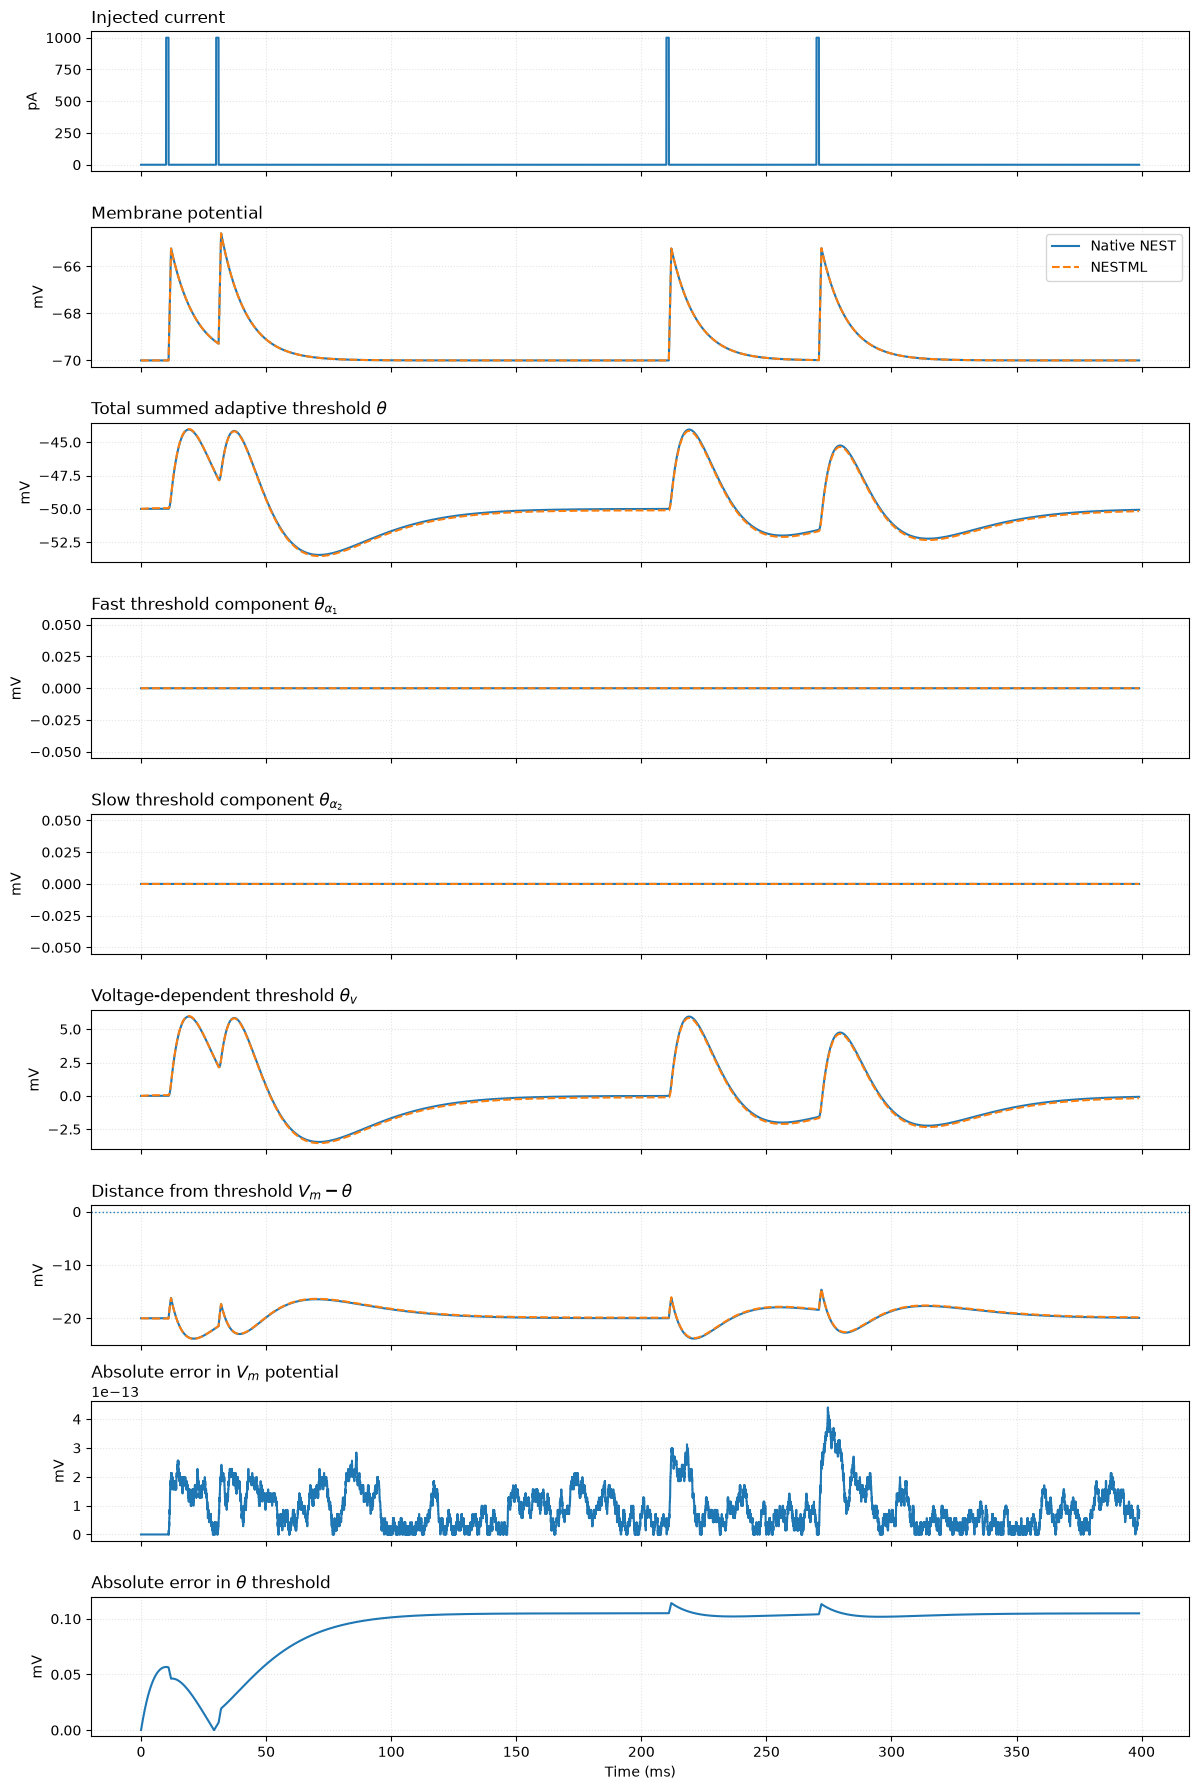

In [17]:
config = AMATConfig()

generated = run_amat_model(nestml_neuron_model, config) # NESTML 
native = run_amat_model(nest_model_name, config) # NEST 

# Reconstructing alpha_1 and alpha_2 for NEST, as it is not in the available recordables. 
native["V_th_alpha_1"] = reconstruct_threshold_component(native["times"], native["spike_times"], config.alpha_1_mv, config.tau_1_ms)
native["V_th_alpha_2"] = reconstruct_threshold_component(native["times"], native["spike_times"], config.alpha_2_mv, config.tau_2_ms,)


print("[INFO] Trace comparison")
for name in ("V_m", "V_th", "V_th_alpha_1", "V_th_alpha_2", "V_th_v"):
    error = generated[name] - native[name]

    print(f"{name:15s} "  # Info error debug
        f"MAE={np.mean(np.abs(error)):.6g}  "  # Mean absolute error (avg error across) 
        f"RMSE={np.sqrt(np.mean(error**2)):.6g}  " # root squared error across sim (penalising large errors)   
        f"max|Δ|={np.max(np.abs(error)):.6g}" # max error recorded  
    )    

print("\n[INFO] Detected spike times")
print("NEST  :", native["spike_times"])
print("NESTML:", generated["spike_times"])

# Plot comparison
fig, axes = plt.subplots(9, 1, figsize=(12, 18), sharex=True)

# Injected current
axes[0].plot(native["times"], native["input_current"])
axes[0].set_ylabel("pA")
axes[0].set_title("Injected current", loc="left")

# Membrane potential
axes[1].plot(native["times"], native["V_m"], label="Native NEST")
axes[1].plot(generated["times"], generated["V_m"], "--", label="NESTML")
axes[1].set_ylabel("mV")
axes[1].set_title("Membrane potential", loc="left")
axes[1].legend()

# Total adaptive threshold
axes[2].plot(native["times"], native["V_th"], label="Native NEST")
axes[2].plot(generated["times"], generated["V_th"], "--", label="NESTML")
axes[2].set_ylabel("mV")
axes[2].set_title(r"Total summed adaptive threshold $\theta$", loc="left")

# Fast spike-history threshold
axes[3].plot(native["times"], native["V_th_alpha_1"], label="Native NEST")
axes[3].plot(generated["times"], generated["V_th_alpha_1"], "--", label="NESTML")
axes[3].set_ylabel("mV")
axes[3].set_title(r"Fast threshold component $\theta_{\alpha_1}$", loc="left")

# Slow spike-history threshold
axes[4].plot(native["times"], native["V_th_alpha_2"], label="Native NEST")
axes[4].plot(generated["times"], generated["V_th_alpha_2"], "--", label="NESTML")
axes[4].set_ylabel("mV")
axes[4].set_title(r"Slow threshold component $\theta_{\alpha_2}$", loc="left")


# Voltage-dependent threshold
axes[5].plot(native["times"], native["V_th_v"], label="Native NEST")
axes[5].plot(generated["times"], generated["V_th_v"], "--", label="NESTML")
axes[5].set_ylabel("mV")
axes[5].set_title(r"Voltage-dependent threshold $\theta_v$", loc="left")

# Distance from threshold
axes[6].plot(native["times"], native["distance"], label="Native NEST")
axes[6].plot(generated["times"], generated["distance"], "--", label="NESTML")
axes[6].axhline(0.0, linestyle=":", linewidth=1)
axes[6].set_ylabel("mV")
axes[6].set_title(r"Distance from threshold $V_m-\theta$", loc="left")

# Membrane-potential error
axes[7].plot(
    native["times"],
    np.abs(generated["V_m"] - native["V_m"]),
)
axes[7].set_ylabel("mV")
axes[7].set_title(r"Absolute error in $V_m$ potential", loc="left")

# Threshold error
axes[8].plot(
    native["times"],
    np.abs(generated["V_th"] - native["V_th"]),
)
axes[8].set_ylabel("mV")
axes[8].set_xlabel("Time (ms)")
axes[8].set_title(r"Absolute error in $\theta$ threshold", loc="left")


# Mark NEST spike times across all model-dynamics panels
for spike_time in native["spike_times"]:
    for ax in axes[:7]:
        ax.axvline(
            spike_time,
            color="red",
            linestyle=":",
            linewidth=1.0,
            alpha=0.7,
        )


for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.35)

plt.tight_layout()
plt.show()

**Discussion** The NEST vs NESTML overlap plot displays an extremely low error across the threshold and V_M components. Furthermore, the distance from thrshold and spiking time (noted as the red-dotted line) is spiking at the same time. Here this clearly shows the NESTML implementation has correctly recreated the NEST AMAT.

In [18]:
import numpy as np

zoom_start = 260.0
zoom_end = 280.0

times = native["times"]
zoom_mask = (times >= zoom_start) & (times <= zoom_end)
indices = np.where(zoom_mask)[0]

print("="*75)
print(f"   DETAILED SYSTEM COMPONENT PROFILER ({zoom_start} ms - {zoom_end} ms)")
print("="*75)

# To keep the output readable while catching the exact drift onset, 
# we print steps where V_th_v or V_m starts to deviate, or when a spike occurs.
last_printed_idx = -100

for idx in indices:
    t = times[idx]
    
    # Calculate current raw deltas
    v_m_delta = generated["V_m"][idx] - native["V_m"][idx]
    v_th_v_delta = generated["V_th_v"][idx] - native["V_th_v"][idx]
    
    # Check if a spike happened on either side in this neighborhood
    is_near_nest_spike = any(abs(t - st) < 0.05 for st in native["spike_times"])
    is_near_nestml_spike = any(abs(t - st) < 0.05 for st in generated["spike_times"])
    
    # Condition: Print if there's a fresh discrepancy, or if we are near a spiking event
    # (Limits repetitive printing of identical steady-state lines)
    if (abs(v_th_v_delta) > 1e-6 and idx - last_printed_idx > 50) or is_near_nest_spike or is_near_nestml_spike:
        
        last_printed_idx = idx
        print(f"\n⏱️  TIMESTAMP: {t:.4f} ms")
        print("-" * 65)
        print(f"{'Variable':<15} | {'Native NEST':<20} | {'NESTML Generated':<20} | {'Raw Delta':<12}")
        print("-" * 65)
        
        metrics = [
            ("V_m", native["V_m"][idx], generated["V_m"][idx]),
            ("V_th_alpha_1", native["V_th_alpha_1"][idx], generated["V_th_alpha_1"][idx]),
            ("V_th_alpha_2", native["V_th_alpha_2"][idx], generated["V_th_alpha_2"][idx]),
            ("V_th_v_aux", native.get("V_th_v_aux", np.zeros_like(times))[idx], generated.get("V_th_v_aux", np.zeros_like(times))[idx]),
            ("V_th_v", native["V_th_v"][idx], generated["V_th_v"][idx]),
            ("V_th", native["V_th"][idx], generated["V_th"][idx])
        ]
        
        for name, nest_val, nestml_val in metrics:
            delta = nestml_val - nest_val
            print(f"{name:<15} | {nest_val:<20.9f} | {nestml_val:<20.9f} | {delta:<+12.9f}")
        print("-" * 65)

print("\n[INFO] Scan complete inside designated window context.")


   DETAILED SYSTEM COMPONENT PROFILER (260.0 ms - 280.0 ms)

⏱️  TIMESTAMP: 260.0000 ms
-----------------------------------------------------------------
Variable        | Native NEST          | NESTML Generated     | Raw Delta   
-----------------------------------------------------------------
V_m             | -69.960841800        | -69.960841800        | +0.000000000
V_th_alpha_1    | 0.000000000          | 0.000000000          | +0.000000000
V_th_alpha_2    | 0.000000000          | 0.000000000          | +0.000000000
V_th_v_aux      | 0.000000000          | -0.131699940         | -0.131699940
V_th_v          | -1.961113036         | -2.064513644         | -0.103400609
V_th            | -51.961113036        | -52.064513644        | -0.103400609
-----------------------------------------------------------------

⏱️  TIMESTAMP: 260.5100 ms
-----------------------------------------------------------------
Variable        | Native NEST          | NESTML Generated     | Raw Delta   
----

## "Resonator" vs. "Integrator" Dynamics in the AMAT Model

This section investigates and validates the characteristics of resonators versus integrators using the AMAT NESTML model. 

Difference between integrator vs. resonator PSC behaviour:
    
- Integrator Behaviour (All-Pass): Acts like a leaky bucket. It accumulates (sums up) all incoming inputs over time, regardless of their timing. It fires a spike when the total input volume exceeds the threshold. It acts as a low-pass filter, favoring high-frequency bursts or closely packed inputs.
- Resonator Behaviour (Band-Pass): Acts like a swing. It is highly sensitive to the specific **timing** and **frequency** of inputs. It prefers a specific inter-pulse interval ($\Delta$). If a second pulse arrives at the peak of the internal oscillation caused by the first pulse, the system "resonates" and triggers a spike. If the timing is off, the inputs cancel out.

These firing behaviours are depicted in the figure A1

<img src="images/integrator_resonator.png" width="1050" height="600">

**Reference:** Yamauchi, S. et al. (2011). *Elemental Spiking Neuron Model for Reproducing Diverse Firing Patterns and Predicting Precise Firing Times* Front. Comput. Neurosci. 
[https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2011.00042/full]

To investigate this firing behaviours the following simulations receives two identical injected currents. The first pulse occurs at 200 ms and the second at `+delta` ms. We measure the largest post-pulse distance `V_m - theta`, whether a spike occurred, and the number of spikes. In this experiment we can also manipulate the neuronal parameters to view the influence of `alpha_1`, `alpha_2` and `V_th` on the firing behaviour. 

The same sweep function is used for native NEST and NESTML, which prevents the two implementations from silently using different timing or analysis rules.

In [8]:
def delta_sweep(
    model_name: str,
    base_config: Any,          # AMATConfig object
    deltas_ms: Sequence[float],
    sweep_type: str = "baseline"  # sweep types "baseline", "gamma", or "beta"
    ) -> list:
    """Run all simulations for a sweep type within a single, unified function."""
    
    sweep_results = []
    
    # Define values to loop over depending on sweep type
    if sweep_type == "gamma":
        print("[INFO] Running gamma delta sweep experiment...")
        loop_param, fixed_param, val_list = "gamma", "B", [0.0, 1.0, 2.0, 3.0, 4.0] # values we are sweeping across 
        fixed_val = 4.0  # fixed beta value
        
    elif sweep_type == "beta":
        print("[INFO] Running beta delta sweep experiment...")
        loop_param, fixed_param, val_list = "B", "gamma", [0.0, 1.0, 2.0, 3.0, 4.0] # values we are sweeping across 
        fixed_val = 1.5  # fixed gamma value 
        
    else:  # baseline mode with no parameter fluctuations
        print("[INFO] Running fixed baseline experiment...")
        loop_param, fixed_param, val_list = "B", "gamma", [0.0, 4.0]  # Integrator (B=0) and Resonator (B=4)
        fixed_val = 1.5 # fixed gamma in baseline experiment. 
        
    # Step through each configuration in the chosen sweep
    for val in val_list:
        
        # Build the exact parameter state for this configuration
        cfg_changes = {loop_param: val, fixed_param: fixed_val}          # build cfg_change with experiment 
        iter_config = dataclasses.replace(base_config, **cfg_changes)    # .replace default values

        # defining label for runs based off sweep_type
        label = (rf"$\gamma$={val:g}" if sweep_type == "gamma" else
            rf"$\beta$={val:g}" if sweep_type == "beta" else
            f"Integrator: B={val:g}, $\gamma$={fixed_val}" if val == 0 else
            f"Resonator: B={val:g}, $\gamma$={fixed_val}")                                                           
        
        runs = []
        
        # Loop through all deltas for this specific value condition 
        for delta in deltas_ms:
            
            second_pulse_ms = iter_config.first_pulse_ms + float(delta)  # calculating second pulse timing 
            
            run_config = dataclasses.replace( # changing the config file with pulse times 
                iter_config,
                pulse_times_ms=(iter_config.first_pulse_ms, second_pulse_ms),  # adjust second pulse and first pulse defaults 
                simulation_time_ms=second_pulse_ms + iter_config.response_window_ms + 20.0)  # compute new relative sim time, save compute 
          
            # Execute model
            traces = run_amat_model(model_name=model_name, config=run_config, sweep_experiment=True)  # utilise previous defined simulation helper function 
            
            # Compute time windows safely
            w = (traces["times"] > second_pulse_ms) & (traces["times"] <= second_pulse_ms + iter_config.response_window_ms) # continous mask trace filter 
            sw = (traces["spike_times"] >= second_pulse_ms) & (traces["spike_times"] <= second_pulse_ms + iter_config.response_window_ms) # spike times mask filter

    
            local_dist = traces["distance"][w] #  distance from V_m to V_th in mask trace 
            p_idx = int(np.argmax(local_dist)) if len(local_dist) > 0 else 0  #  idx during local_dist occured 
        
            # Save raw data for this specific run, i'm a bit unsure why we are saving so much here? also do we need to save the label for this? 
            runs.append({
                "delta_ms": float(delta),
                "spike_after_second": bool(np.any(sw)),
                "n_spikes_after_second": int(np.sum(sw)),
                "max_distance_mv": float(np.max(local_dist)) if len(local_dist) > 0 else 0.0,
                "time_of_max_distance_ms": float(traces["times"][w][p_idx]) if len(local_dist) > 0 else 0.0,
                "peak_voltage_mv": float(np.max(traces["V_m"][w])) if len(traces["V_m"][w]) > 0 else 0.0,
                "traces": traces  # Keeping raw data if you want to inspect a specific trace later
            })
            
        print("[INFO] Finished Sweep Iteration")
        
        # Compile everything directly into the final sweep dictionary
        sweep_results.append({
            "label": label,  # Saved correctly at the top level
            "model_name": model_name,
            "deltas_ms": np.asarray(deltas_ms, dtype=float),
            "spike_after_second": np.asarray([r["spike_after_second"] for r in runs], dtype=bool),
            "n_spikes_after_second": np.asarray([r["n_spikes_after_second"] for r in runs], dtype=int),
            "max_distance_mv": np.asarray([r["max_distance_mv"] for r in runs], dtype=float),
            "time_of_max_distance_ms": np.asarray([r["time_of_max_distance_ms"] for r in runs], dtype=float),
            "peak_voltage_mv": np.asarray([r["peak_voltage_mv"] for r in runs], dtype=float),
            "runs": runs,
            "config": iter_config,
        })
        
    return sweep_results

# define delta ISI
deltas = np.arange(2.0, 150.0, 2.0)

# Simply select your experiment profile by changing the string input!
gamma_sweeps = delta_sweep(nestml_neuron_model, config, deltas, sweep_type="gamma")
beta_sweeps  = delta_sweep(nestml_neuron_model, config, deltas, sweep_type="beta")

<>:37: SyntaxWarning:invalid escape sequence '\g'
<>:38: SyntaxWarning:invalid escape sequence '\g'
<>:37: SyntaxWarning:invalid escape sequence '\g'
<>:38: SyntaxWarning:invalid escape sequence '\g'
/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/ipykernel_7101/52587868.py:37: SyntaxWarning:invalid escape sequence '\g'
/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/ipykernel_7101/52587868.py:38: SyntaxWarning:invalid escape sequence '\g'


[INFO] Running gamma delta sweep experiment...
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Running beta delta sweep experiment...
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration


$\gamma$=0.5 | Optimal Delta ISI:   2.0 ms | Peak Margin from V_th:  -0.03 mV) | Spiked across interval: 2.0 to 26.0 ms (10 steps)
$\gamma$=1 | Optimal Delta ISI:  48.0 ms | Peak Margin from V_th:  -0.03 mV) | Spiked across interval: 24.0 to 46.0 ms (12 steps)
$\gamma$=1.5 | Optimal Delta ISI:  62.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 30.0 to 68.0 ms (20 steps)
$\gamma$=2 | Optimal Delta ISI:  88.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 38.0 to 86.0 ms (25 steps)
$\gamma$=2.5 | Optimal Delta ISI:  48.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 44.0 to 106.0 ms (32 steps)
$\gamma$=3 | Optimal Delta ISI:  96.0 ms | Peak Margin from V_th:  -0.01 mV) | Spiked across interval: 50.0 to 126.0 ms (39 steps)
$\gamma$=3.5 | Optimal Delta ISI: 134.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 56.0 to 144.0 ms (45 steps)
$\gamma$=4 | Optimal Delta ISI:  80.0 ms | Peak Margin from V_th:  -0.02 mV) | S

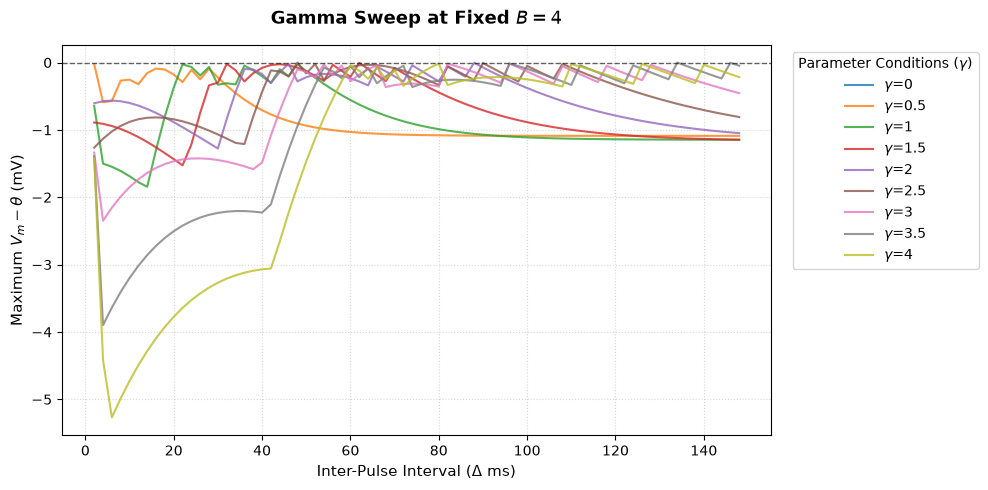

$\beta$=0 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 28.0 ms (14 steps)
$\beta$=0.5 | Optimal Delta ISI:  28.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 26.0 ms (13 steps)
$\beta$=1 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 52.0 ms (15 steps)
$\beta$=1.5 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 58.0 ms (16 steps)
$\beta$=2 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 62.0 ms (17 steps)
$\beta$=2.5 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 64.0 ms (18 steps)
$\beta$=3 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 66.0 ms (19 steps)
$\beta$=3.5 | Optimal Delta ISI:  60.0 ms | Peak Margin from V_th:  -0.01 mV) | Spiked across inte

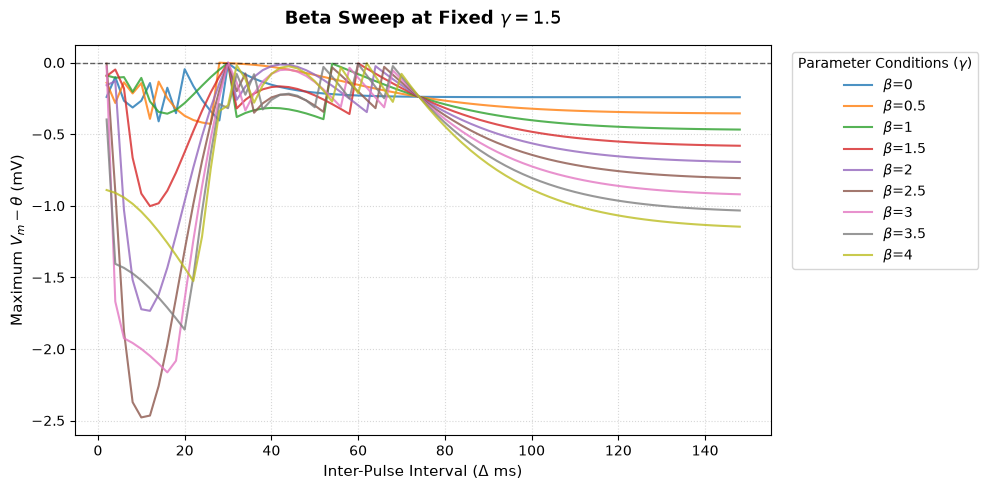

In [9]:
def plot_sweep_experiment(sweeps_list, title="Sweep Experiment"):
   
    plt.figure(figsize=(10, 5), dpi=100)

    # parameter inference directly from your custom title string
    sweep_param = r"$\gamma$" if "gamma" in title.lower() else (r"$\beta$" if "beta" in title.lower() else "Baseline")

    for sweep in sweeps_list: # Iterate through each tracked parameter configuration in the list
        label = sweep["label"]
        deltas = sweep["deltas_ms"]
        y_vals = sweep["max_distance_mv"]     # Hardcoded directly to your variable
        spiked = sweep["spike_after_second"]   # Boolean array tracking spike events
    
        line, = plt.plot(deltas, y_vals, label=label, linewidth=1.5, alpha=0.8)   # Plot baseline subthreshold metric line
        
        best_idx = int(np.argmax(y_vals)) # peak sensitvity (highest V_m - V_th) index 
        best_delta = deltas[best_idx]  # given peak sensitivity, what was the delta? 
        best_margin = y_vals[best_idx] # given peak sensitvity, what was the V_m-V_th diff 
        
        # Check spike ranges
        total_spikes = int(np.sum(spiked))   # summed number of ISI spikes 
        if total_spikes > 0:
            spike_indices = np.flatnonzero(spiked) # returns flat array of true spike indices 
            range_str = f"{deltas[spike_indices[0]]:.1f} to {deltas[spike_indices[-1]]:.1f} ms" # [0] lower bound [-1] upper bound of senstivity 
            spike_info = f"Spiked across interval: {range_str} ({total_spikes} steps)" # num of spikes in this sensitivity area 
            print(f"{label} | Optimal Delta ISI: {best_delta:>5.1f} ms | Peak Margin from V_th: {best_margin:>6.2f} mV) | {spike_info}")
            
    plt.axhline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.6)  # Structural elements and neuroscientific annotations
    plt.title(title, fontsize=13, fontweight="bold", pad=15)
    plt.xlabel(r"Inter-Pulse Interval ($\Delta$ ms)", fontsize=11)
    plt.ylabel(r"Maximum $V_m - \theta$ (mV)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.5)   # grid layout
    plt.legend(title=f"Parameter Conditions ({sweep_param})", bbox_to_anchor=(1.02, 1), loc='upper left')  # legend placement
    plt.tight_layout()
    plt.show()

# Gamma Sweep 
plot_sweep_experiment(gamma_sweeps, 
    title=r"Gamma Sweep at Fixed $B=4$")

# Beta Sweep 
plot_sweep_experiment(beta_sweeps, 
    title=r"Beta Sweep at Fixed $\gamma=1.5$")


**Conclusion** Here we can see for fixed beta experiments manipulating the gamma parameter in the amat neuronal model produces.. Whereas, when we manipulate the beta parameters keeping the gamma fixed we see ...

### Main comparison: integrator control and resonator condition

`B=0` disables the voltage-dependent threshold contribution and acts as the
MAT-like control. `B=4` activates that contribution. Both conditions are run
through native NEST and NESTML so implementation agreement can be inspected.

We can view the influence of the voltage-dependent threshold contribution towards resonator and integrator 
firing behaviours.


[INFO] Running fixed baseline experiment...
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
[INFO] Running fixed baseline experiment...
[INFO] Finished Sweep Iteration
[INFO] Finished Sweep Iteration
Integrator: B=0, $\gamma$=1.5 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 28.0 ms (14 steps)
Resonator: B=4, $\gamma$=1.5 | Optimal Delta ISI:  62.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 30.0 to 68.0 ms (20 steps)


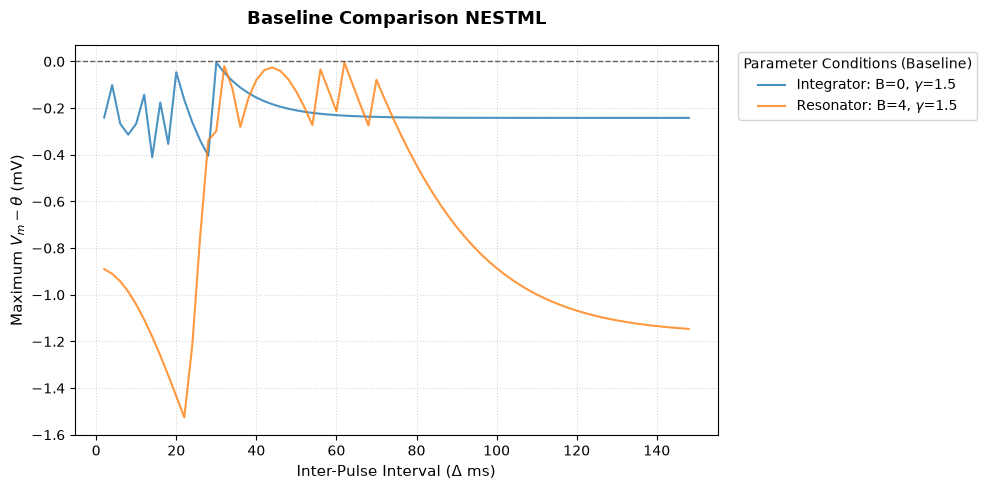

Integrator: B=0, $\gamma$=1.5 | Optimal Delta ISI:  30.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 2.0 to 28.0 ms (14 steps)
Resonator: B=4, $\gamma$=1.5 | Optimal Delta ISI:  62.0 ms | Peak Margin from V_th:  -0.00 mV) | Spiked across interval: 30.0 to 68.0 ms (20 steps)


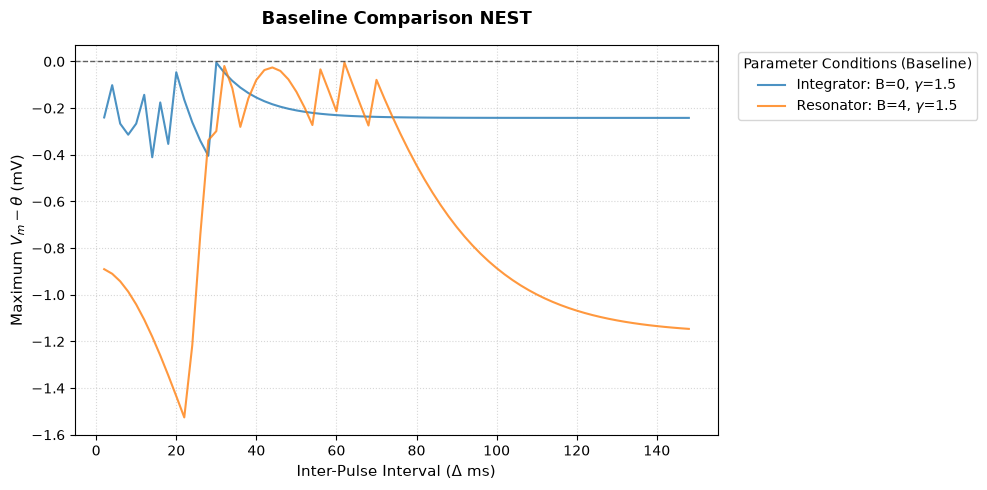

In [10]:
# Re-use previous functions for beta and gamma sweeps 
nestml_baseline = delta_sweep(nestml_neuron_model, config, deltas, sweep_type="baseline") # NESTML 
nest_baseline = delta_sweep(nest_model_name, config, deltas, sweep_type="baseline") # NESTML 

plot_sweep_experiment(nestml_baseline, 
    title="Baseline Comparison NESTML")

plot_sweep_experiment(nest_baseline, 
        title="Baseline Comparison NEST")

**Conclusion** When comparing across NESTML and NEST with these beta and gamma values we see... 

## Brunel Balanced network using AMAT neurons

After NESTML AMAT validation, we can benchmark the model to ensure the model C++ compilation code is running optimially. In these benchmarking experiments, a **brunel balanced network** is utilised. 

A brunel Balanced Network Model is a neural network model that examines how neural stability is maintained through the near-perfect cancellation of massive excitatory and inhibitory currents. By providing a framework for E/I balance, the model can display the emergence of asynchronous and irregular firing behaviours by shifting the E/I balance, connectivity schematic displayed below.  

<img src="images/balanced_schematic.png" width="250" height="150">


**Reference** Brunel, *N. Dynamics of Sparsely Connected Networks of Excitatory and Inhibitory Spiking Neurons*. J Comput Neurosci 8, 183–208 (2000). https://doi.org/10.1023/A:1008925309027



In [19]:
def exp_psp_norm(
    tau_m: float, # The membrane time constant, leak back to rest
    C_m: float,   # The membrane capacitance, charge required to change the voltage.
    tau_syn: float) -> float:  # synaptic decay, how fast the input decays 
    """This function calculates synaptic weight multiplier to transform PSC (post synaptic current) 
    into a voltage change of exactly 1.0 mV. 
    """
    if np.isclose(tau_m, tau_syn): #  avoid dividing by 0
        return tau_m / (np.e * C_m) # lehospital reduction 
        
    t_peak = (tau_m * tau_syn / (tau_m - tau_syn) * np.log(tau_m / tau_syn)) # find timepoint when PSC reaches peak 
    
    # scaling factor, plug t_peak back into LIF ODE. 
    return (tau_m * tau_syn / (C_m * (tau_m - tau_syn)) * (np.exp(-t_peak / tau_m) - np.exp(-t_peak / tau_syn))) 

def run_balanced_network(
    model_name: str,
    input_type: str = "static" # "static", "inh_push", or "exc_push"
):
    
    config = AMATConfig() # reinstantiate config if updates are made 
    events_ex_dict = {}
    events_in_dict = {}

    NE = 4 * config.order # neuron num of exc (80%)
    NI = 1 * config.order # neuron num of inh (20%)
    N_neurons = NE + NI 
    
    # connection parameters 
    CE = int(config.epsilon * NE)  # Exc conns 
    CI = int(config.epsilon * NI)  # Inh conns 
  
    N_rec_E = NE  # Record all excitatory
    N_rec_I = NI  # Record all inhibitory
        
    # Process normalisation coefficients using params  
    norm_ex = exp_psp_norm(config.tau_m_ms, config.C_m_pf, config.tau_syn_ex_ms)
    norm_in = exp_psp_norm(config.tau_m_ms, config.C_m_pf, config.tau_syn_in_ms)
    
    # First calculate the correct normalized excitatory current amplitude
    J_ex = config.J_ex / norm_ex
    
    # background poisson drive 
    delta_V = config.resting_threshold_mv - config.E_L_mv
    baseline_current = (delta_V * config.C_m_pf) / config.tau_m_ms
    baseline_rate_hz = (1000.0 * baseline_current) / (J_ex * config.tau_syn_ex_ms)
    external_rate_hz = config.eta * baseline_rate_hz

    if input_type == "static":
        pass # dont affect default synaptic balance ratio (g)) 

    elif input_type == "inh_push": 
        config = replace(config, g=config.g * 2.0) # Make inhibitory synapses 1.75x stronger than baseline
    
    elif input_type == "exc_push":
        config = replace(config, g=config.g * 0.5)
        external_rate_hz = external_rate_hz * 1.75 

    # requested target millivolt amplitudes directly from your explicit weights 
    target_psp_ex_mv = config.J_ex  # e.g., 0.15 mV target amplitude
    target_psp_in_mv = config.J_in  # e.g., 0.75 mV target amplitude (g * J_ex handled at dataclass level)
    
     # Force the inhibitory current amplitude to be exactly g times larger than J_ex
    J_in = -config.g * J_ex  

    nest.ResetKernel() # reset kernel, clean slate with any pre-existing param values etc. 
    nest.resolution = config.resolution
    nest.local_num_threads = 1 # Force single thread locally to test stability. can manipulate with HPC. 
    nest.rng_seed = 12345
    nest.print_time = True
    nest.set_verbosity("M_ERROR")

    if model_name not in nest.Models():
        nest.Install("nestml_amat_module")

    n_processes = nest.NumProcesses()   # Total MPI processes across the whole cluster
    n_threads = nest.local_num_threads  # OpenMP threads running inside each process
    total_cores = n_processes * n_threads # Calculate total execution power

    print(f"Balanced Network configuration: {model_name}")
    print(f"Neurons Profile    : {N_neurons} total ({NE} Excitatory, {NI} Inhibitory)")
    print(f"Network Connectivity   : CE = {CE}, CI = {CI}")
    print(f"Excitatory Weight  : {J_ex:.6f} pA")
    print(f"Inhibitory Weight  : {J_in:.6f} pA")
    print(f"External Drive Rate: {external_rate_hz:.3f} Hz/neuron")
        
    # Map dataclass properties into expected NEST parameter updates
    neuron_params = {"tau_m": config.tau_m_ms, "C_m": config.C_m_pf, "E_L": config.E_L_mv, 
                     "alpha_1": config.alpha_1_mv, "alpha_2": config.alpha_2_mv}
    
    start_build = time.perf_counter() 
    
    neurons_ex = nest.Create(model_name, NE, params=neuron_params)
    neurons_in = nest.Create(model_name, NI, params=neuron_params)
    neurons = neurons_ex + neurons_in
    
    # Generate external stimuli and recorders
    noise = nest.Create("poisson_generator", params={"rate": external_rate_hz})
    spikes_ex = nest.Create("spike_recorder")
    spikes_in = nest.Create("spike_recorder")
    
    # External excitation.
    nest.Connect(noise, neurons, syn_spec={"weight": J_ex, "delay": config.delay})
        
    # Record from all excitatory and inhibitory populations 
    nest.Connect(neurons_ex[N_rec_E], spikes_ex)
    nest.Connect(neurons_in[N_rec_I], spikes_in)
    
    # Recurrent excitation.
    nest.Connect(neurons_ex, neurons, conn_spec={"rule": "fixed_indegree", "indegree": CE}, 
                 syn_spec={"weight": J_ex, "delay": config.delay})
    
    # Recurrent inhibition. Negative NEST weights are routed to the
    # NESTML inhibitory spike port; the model then applies the negative sign.
    nest.Connect(neurons_in, neurons, conn_spec={"rule": "fixed_indegree", "indegree": CI},
            syn_spec={"weight": J_in, "delay": config.delay})
    
    build_time = time.perf_counter() - start_build
    
    print(f"Starting simulation for {config.balanced_simtime} ms.")
    start_sim = time.perf_counter()
    nest.Simulate(config.balanced_simtime)
    simulation_time = time.perf_counter() - start_sim

    # Safely capture event rates to prevent division errors on small local windows
    events_count_ex = int(spikes_ex.n_events)
    events_count_in = int(spikes_in.n_events)
    
    # extract the actual raw array data for your plots!
    events_ex_dict = nest.GetStatus(spikes_ex, "events")[0]
    events_in_dict = nest.GetStatus(spikes_in, "events")[0]
    
    # Compute mean firing rate per neuron in Hz
    rate_ex = (events_count_ex * 1000.0) / (config.balanced_simtime * N_rec) if N_rec > 0 else 0.0
    rate_in = (events_count_in * 1000.0) / (config.balanced_simtime * N_rec) if N_rec > 0 else 0.0

    scaling_results = { 
        # Parallel Engine Topology
        "n_threads": int(n_threads),
        "mpi_processes": int(n_processes),
        "n_threads_per_process": int(n_threads),
        "total_cores": int(n_processes * n_threads),
    
        # Execution Footprints (The Wall Clocks)
        "build_time_s": float(build_time),
        "simulation_time_s": float(simulation_time), 
        "total_wall_clock_s": float(build_time + simulation_time),  # 
        
        # Network Load Properties & Rates
        "input_type": str(input_type),   # "static", "inh_push", or "exc_push"
        "total_neurons": int(N_neurons),
        "total_synapses": int(N_neurons * (CE + CI)),
        "events_ex_dict": events_ex_dict, 
        "events_in_dict": events_in_dict,
        "total_spikes_captured": int(events_count_ex + events_count_in),
        "exc_rate_hz": float(rate_ex),  
        "inh_rate_hz": float(rate_in)
    } 

    print(f"Scaling results: {model_name}")
    for k, v in scaling_results.items():
        if k in ["events_ex_dict", "events_in_dict"]:    # avoid printing massive dicts 
            continue
        else:
            print(f"{k:<22}: {v}")
    
    return scaling_results

nestml_balanced_df = run_balanced_network(nestml_neuron_model, "inh_push")
nest_balanced_df = run_balanced_network(nest_model_name, "inh_push") 

Balanced Network configuration: amat_neuron_nestml
Neurons Profile    : 2500 total (2000 Excitatory, 500 Inhibitory)
Network Connectivity   : CE = 200, CI = 50
Excitatory Weight  : 38.746490 pA
Inhibitory Weight  : -387.464900 pA
External Drive Rate: 3871.318 Hz/neuron
Starting simulation for 1000.0 ms.
Scaling results: amat_neuron_nestml
n_threads             : 1
mpi_processes         : 1
n_threads_per_process : 1
total_cores           : 1
build_time_s          : 0.10709100000167382
simulation_time_s     : 4.660321625000506
total_wall_clock_s    : 4.76741262500218
input_type            : inh_push
total_neurons         : 2500
total_synapses        : 625000
total_spikes_captured : 956
exc_rate_hz           : 4.78
inh_rate_hz           : 4.78
Balanced Network configuration: amat2_psc_exp
Neurons Profile    : 2500 total (2000 Excitatory, 500 Inhibitory)
Network Connectivity   : CE = 200, CI = 50
Excitatory Weight  : 38.746490 pA
Inhibitory Weight  : -387.464900 pA
External Drive Rate: 387

**Results Discussion** Here we can see a low excitatory and inhibitory here? We can also see different build and simulation times of NEST and NESTML, NEST will be utilising different memory configurations and has been previously built upon the NESTML system so they will have drastically lower build and simulation times, interesting to note!


## Plotting network activity and interspike interval profiles of NEST and NESTML 

After running brunel balanced network simulations for `amat_neuron_nestml` and `amat2_psc_exp`, we can analyse the network dynamics using a number of visualisations: 

* **Population Raster Plots:** Enables tracking of individual spike timings and compare the firing patterns of excitatory and inhibitory populations across both model implementations.
* **Interspike Interval (ISI) Distributions:** Investigating underlying spiking profiles. This plot displays the frequency of occurrence (%) of specific time intervals between consecutive spikes from the same neuron.


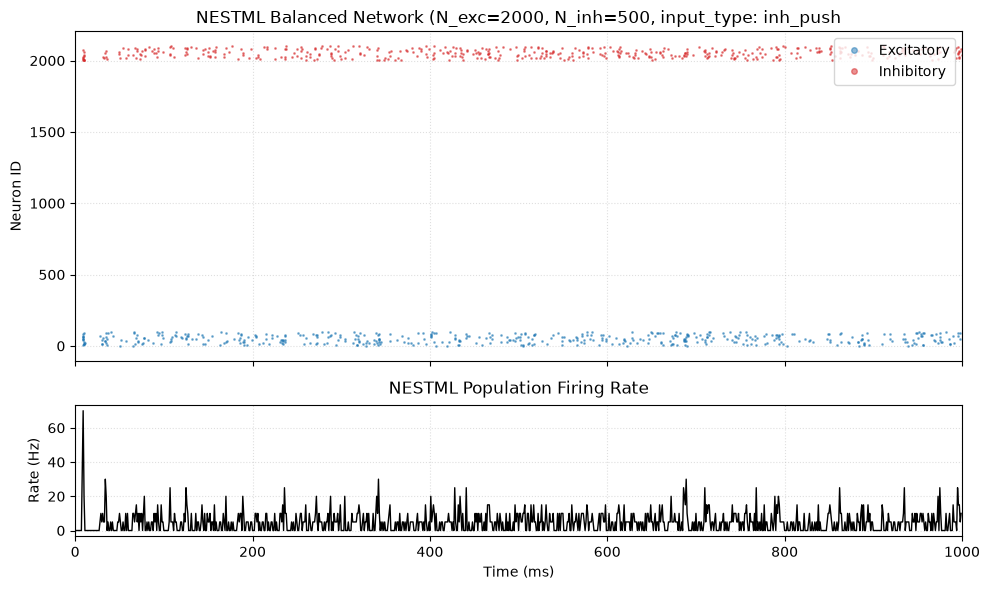

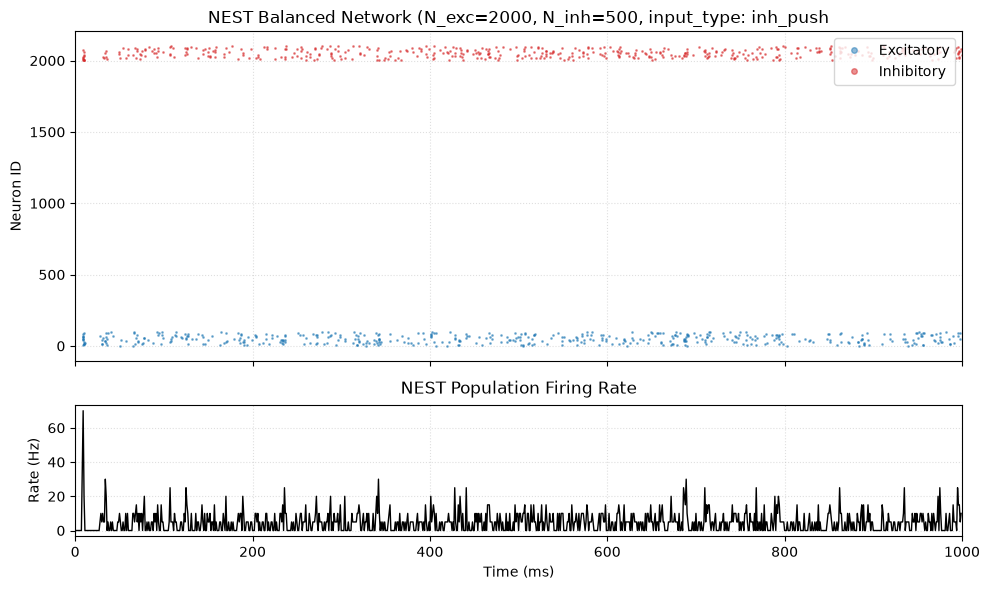

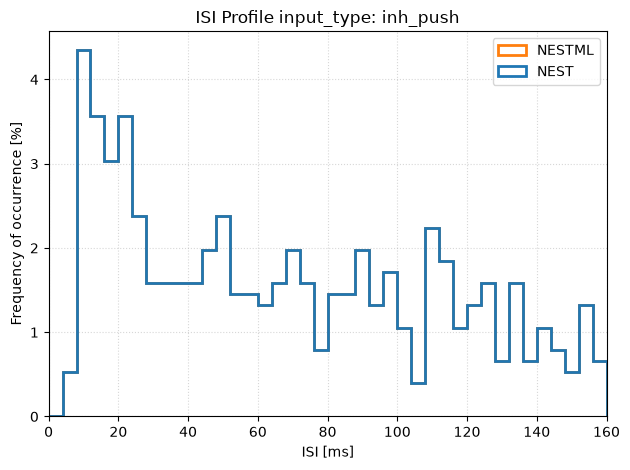

In [20]:
def raster_profile(
    model_type: str, 
    ev_ex: dict, 
    ev_in: dict,
    input_type: str): 

    config = AMATConfig() # reinstantiate config if updates are made 

    # Extract times and senders directly from the passed-in dictionaries
    t_ex, s_ex = ev_ex["times"], ev_ex["senders"]
    t_in, s_in = ev_in["times"], ev_in["senders"]

    # configure a multi-panel canvas tracking timeline trends
    fig, (ax_raster, ax_rate) = plt.subplots(
        2, 1, figsize=(10, 6), sharex=True, 
        gridspec_kw={"height_ratios": [2.5, 1]}
    )
    
    # panel 01 raster plot that tracks individual spikes over time across your recorded neuron population
    ax_raster.plot(t_ex, s_ex, ".", color="tab:blue", markersize=2, label="Excitatory", alpha=0.5)
    ax_raster.plot(t_in, s_in, ".", color="tab:red", markersize=2, label="Inhibitory", alpha=0.5)
    
    ax_raster.set_ylabel("Neuron ID")
    ax_raster.set_title(f"{model_type} Balanced Network (N_exc={(config.order * 4)}, N_inh={(config.order * 1)}, input_type: {input_type}", fontsize=12)
    ax_raster.legend(loc="upper right", markerscale=4, frameon=True)
    ax_raster.grid(True, linestyle=":", alpha=0.4)
    
    ax_rate.set_title(f"{model_type} Population Firing Rate", fontsize=12, pad=8)
    all_spikes = np.concatenate([t_ex, t_in])
    bins = np.arange(0, config.balanced_simtime + 1.0, 1.0)
    
    # Render tracking curves seamlessly across available spike arrays
    if len(all_spikes) > 0:
        counts, edges = np.histogram(all_spikes, bins=bins)
        pop_hz = (counts * 1000.0) / (1.0 * (config.n_record * 2))
        ax_rate.plot(edges[:-1], pop_hz, color="black", linewidth=1.0)
    else:
        ax_rate.text(0.5, 0.5, "No spikes recorded", ha="center", va="center", color="gray")
    ax_rate.set_xlabel("Time (ms)")
    ax_rate.set_ylabel("Rate (Hz)")
    ax_rate.set_xlim(0, config.balanced_simtime)
    ax_rate.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()

def isi_profile(ev_ex_nestml: dict, ev_in_nestml: dict,
    ev_ex_nest: dict, ev_in_nest: dict, input_type: str): 

    config = AMATConfig() # reinstantiate config if updates are made 
    bins = np.arange(0, 164, 4) # 4ms bins up to 160ms (Linssen 2025 et al.,)
    
    variants = [("NESTML", ev_ex_nestml, ev_in_nestml, "tab:orange"), ("NEST", ev_ex_nest, ev_in_nest, "tab:blue")]
    
    for label, ex, inh, color in variants:
        isis = []
        # Calculate intervals per individual neuron
        for data in [ex, inh]:
            for neuron in np.unique(data["senders"]):
                spikes = np.sort(data["times"][data["senders"] == neuron])
                if len(spikes) > 1:
                    isis.extend(np.diff(spikes))
        
        # Plot normalized histogram
        if isis:
            weights = np.ones_like(isis) / len(isis) * 100
            plt.hist(isis, bins=bins, weights=weights, histtype="step", linewidth=2, color=color, label=label)

    plt.xlabel("ISI [ms]")
    plt.ylabel("Frequency of occurrence [%]")
    plt.title(f"ISI Profile input_type: {input_type}", fontsize=12)
    plt.xlim(0, 160)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Execution calls 
raster_profile(model_type="NESTML", ev_ex=nestml_balanced_df["events_ex_dict"], ev_in=nestml_balanced_df["events_in_dict"], input_type=nestml_balanced_df["input_type"])
raster_profile(model_type="NEST", ev_ex=nest_balanced_df["events_ex_dict"],  ev_in=nest_balanced_df["events_in_dict"], input_type=nest_balanced_df["input_type"])

isi_profile(
    ev_ex_nestml=nestml_balanced_df["events_ex_dict"], ev_in_nestml=nestml_balanced_df["events_in_dict"], 
    ev_ex_nest=nest_balanced_df["events_ex_dict"], ev_in_nest=nest_balanced_df["events_in_dict"], input_type=nest_balanced_df["input_type"]) 
# just pass one input type in since both conditions will be the same 


## Scaling vs Non-Scaling Benchmarks 


<img src="images/performance_benchmark.png" width="1050" height="600">

<img src="images/isi_profile.png" width="1050" height="600">

<img src="images/.png" width="1050" height="600">

<img src="images/.png" width="1050" height="600">




The final section here analyses the behaviour we discussed previously with NESTML and NEST performance . 

benchma
But this is the a larger network size performed across multiple high performance computers (nodes) in which we ran simulations to see how it would affect the modle if we scaled it ?

with weak scaling increasing the problem size (network size) and also the compute capability
with strong scaling increasing the compute capabiltieis 

These types of 


*Please note this data was simulated in a high-performance computing environment*

Acknowledgements
----------------

Developed by: Angus Gray

My thanks to the organisers of the JSC Guest Student Programme 2026 and to my supervisor Charl Linssen for his guidance throughout this project. 

This software was developed in part or in whole in the Human Brain Project, funded from the European Union’s Horizon 2020 Framework Programme for Research and Innovation under Specific Grant Agreements No. 720270 and No. 785907 (Human Brain Project SGA1 and SGA2).

License
-------

This notebook (and associated files) is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 2 of the License, or (at your option) any later version.

This notebook (and associated files) is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.